# Đặt vấn đề
**1. Ví dụ 1: Tính hàm giai thừa $F(n) = n!$**

- Định nghĩa thông thường: $n! = 1.2...(n-1).n$
- Định nghĩa đệ quy (Recursive definition):
    - Với $n \ge 1: n! = (n-1)!.n$
    - Với $n = 0$: 0! = 1
- Mã giả (pseudocode):
    - Input: Một số nguyên không âm n
    - Output: Giá trị n!
    - if n = 0 return 1: Đây là base case hay điểm dừng. Nếu không có dòng này, thuật toán sẽ đệ quy mãi mãi
    - else return F(n-1)*n: Đây là bước đệ quy. Nó gọi lại chính hàm F với giá trị nhỏ hơn (n - 1) rồi nhân kết quả đó với n
- Phân tích toán học
    - Kích thước đầu vào (input size): Được xác định bởi chính giá trị n
    - Phép toán cơ bản (Basic Operation): Là phép nhân
        - Vì trong dòng return F(n - 1) * n, công việc chính mà CPU phải làm sau khi có kết quả của F(n - 1) là nhân nó với n 
    - Kí hiệu: $M(n)$: Là số lần thực hiện phép nhân để tính F(n)
- Ta có công thức:
$$F(n) = F(n-1) \cdot n \text{ for } n > 0$$

- Đây là bước đệm để thiết lập Hệ thức truy hồi (Recurrence Relation) cho độ phức tạp

# Xây dựng mô hình toán học

**Phần 1. Thiết lập hệ thức truy hồi**

**1. Xây dựng phương trình cho $M(n)$**

- Ta phân tích số lượng phép nhân $M(n)$
    - Logic: Để tính $F(n)$, máy tính cần tính xong $F(n-1)$ (tốn $M(n-1)$ phép nhân), sau đó thực hiện thêm 1 phép nhân nữa (lấy kết quả đó nhân với n)
    - Phương trình:
    $$M(n) = M(n-1) + 1 \text{ với } n > 0$$
- Hình tượng hóa phương trình: $M(n) = M(n-1) + 1$
    - Sự bất lực của bạn: Bạn cầm số 5 trên tay, nhưng bạn không thể nhân được vì bạn chưa biết (5-1)! là bao nhiêu
    - Hành động 'Ủy thác' (Đệ quy): Bạn quay sang vỗ vai ông số 4 (F(4)) và bảo: "Tính giùm tôi 4! đi, chừng nào xong đưa kết quả đây để tôi nhân với số 5 của tôi"
        - Lúc này, bạn đang ngồi chờ. Bạn chưa làm phép nhân nào cả
        - Toàn bộ 'gánh nặng' tính toán bây giờ chuyển sang cho ông số 4 (đó chính là $M(n - 1)$)
    - Hành động của riêng bạn: Sau một hồi, Ông số 4 đưa cho bạn kết quả (là 24). Bây giờ bạn mới bắt đầu làm việc của mình là 24 x 5
        - Lúc này bạn thực hiện đúng 1 phép nhân
    - Kết luận: Tổng số phép nhân để giải quyết bài toán của bạn là ($M(n)$) = Số phép nhân mà thằng cấp dưới phải làm ($M(n - 1)$) + 1 phép nhân mà chính tay ta làm ở bước cuối

**2. Khái niệm Hệ thức truy hồi**

- Phương trình trên gọi là Hệ thức truy hồi
    - Định nghĩa: Là phương trình định nghĩa giá trị của hàm số ($M(n)$) dựa trên giá trị của nó tại một điểm khác ($M(n-1)$)
    - Tuy nhiên, một phương trình truy hồi có thể có vô số nghiệm. Để tìm ra nghiệm duy nhất, ta cần một điểm xuất phát

**3. Tìm điều kiện khởi tạo**

- Để giải phương trình, ta cần biết thuật toán dừng lại ở đâu
    - Nhìn vào mã giả: if n = 0 return 1
    - Khi n = 0, thuật toán trả về 1 ngay lập tức mà không cần thực hiện phép nhân nào
    - Do đó $M(0) = 0$
- Ta đã thiết lập được mô hình toán học hoàn chỉnh
$$\begin{cases}
M(n) = M(n-1) + 1 & \text{với } n > 0 \\
M(0) = 0
\end{cases}$$

**Phần 2: Giải hệ thức truy hồi (Backward Substitution)**

**1. Bước 1: Nguyên lý 'Cái hộp bên trong'**

- Hệ thức $M(n) = M(n - 1) + 1$ nói lên rằng: 'Giá trị của hộp to (n) bằng giá trị của hộp nhỏ hơn bên trong nó (n - 1) cộng thêm 1 đồng tiền công mở hộp'
- Nhưng ta chưa biết giá trị hộp nhỏ bên trong là bao nhiêu, nên ta phải mở tiếp

**2. Bước 2: Quá trình bóc tách (Thay thế ngược)**

- Lớp thứ 1 (Bắt đầu):
$$M(n) = \underbrace{M(n-1)}_{\text{Hộp chưa mở}} + 1$$
- Lớp thứ 2 (Thay thế lần 1): Ta biết $M(n-1)$ lại bằng $M(n-2) + 1$. Hãy thay thế nó vào:
$$M(n) = [\underbrace{M(n-2) + 1}_{\text{Nội dung hộp } n-1}] + 1$$
Rút gọn lại: $M(n) = M(n-2) + 2$
- Lớp thứ 3 (Thay thế lần 2):
Tiếp tục, $M(n-2)$ lại bằng $M(n-3) + 1$. Thay vào tiếp:
$$M(n) = [\underbrace{M(n-3) + 1}_{\text{Nội dung hộp } n-2}] + 2$$

Rút gọn lại: $M(n) = M(n-3) + 3$

**3. Bước 3: Nhìn ra quy luật (Pattern Recognition)**

- Khi bên trong là (n - 1), thì cộng thêm 1 bên ngoài
- Khi bên trong là (n - 2), thì cộng thêm 2 bên ngoài

$\Rightarrow$ Quy luật tổng quát:
Nếu ta bóc đến lớp thứ $i$, công thức sẽ là:
$$M(n) = M(n - \mathbf{i}) + \mathbf{i}$$

**4. Bước 4: Tìm điểm dừng (Dựa vào điều kiện ban đầu)**

- Chúng ta không thể bóc mãi được. Chúng ta phải bóc cho đến khi chạm tới 'cái lõi' cuối cùng mà ta đã biết giá trị. Cái lõi đó chính là $M(0) = 0$ 
- Để trong ngoặc đơn xuất hiện số 0, thì:
$$n - i = 0 \Rightarrow \mathbf{i = n}$$

Nghĩa là: "Để chạm tới đáy hộp số 0, ta phải bóc đúng $n$ lần."

**5. Bước 5: Kết quả cuối cùng**
- Bây giờ, hãy áp dụng $i = n$ vào công thức tổng quát ở Bước 3:
$$M(n) = M(n - n) + n$$
$$M(n) = \underbrace{M(0)}_{\text{Cái lõi = 0}} + n$$
$$M(n) = 0 + n$$
$$\Rightarrow \mathbf{M(n) = n}$$


**6. Tóm tắt**

- Tưởng tượng bạn cần tính $M(5)$.
    - Mở hộp 5 $\rightarrow$ thấy hộp 4 + 1 đồng.
    - Mở hộp 4 $\rightarrow$ thấy hộp 3 + 1 đồng.
    - Mở hộp 3 $\rightarrow$ thấy hộp 2 + 1 đồng.
    - Mở hộp 2 $\rightarrow$ thấy hộp 1 + 1 đồng.
    - Mở hộp 1 $\rightarrow$ thấy hộp 0 + 1 đồng.
    - Hộp 0 rỗng tuếch (giá trị 0).
- Tổng kết: Bạn thu được 5 đồng tiền công.
Vậy độ phức tạp là $O(n)$.

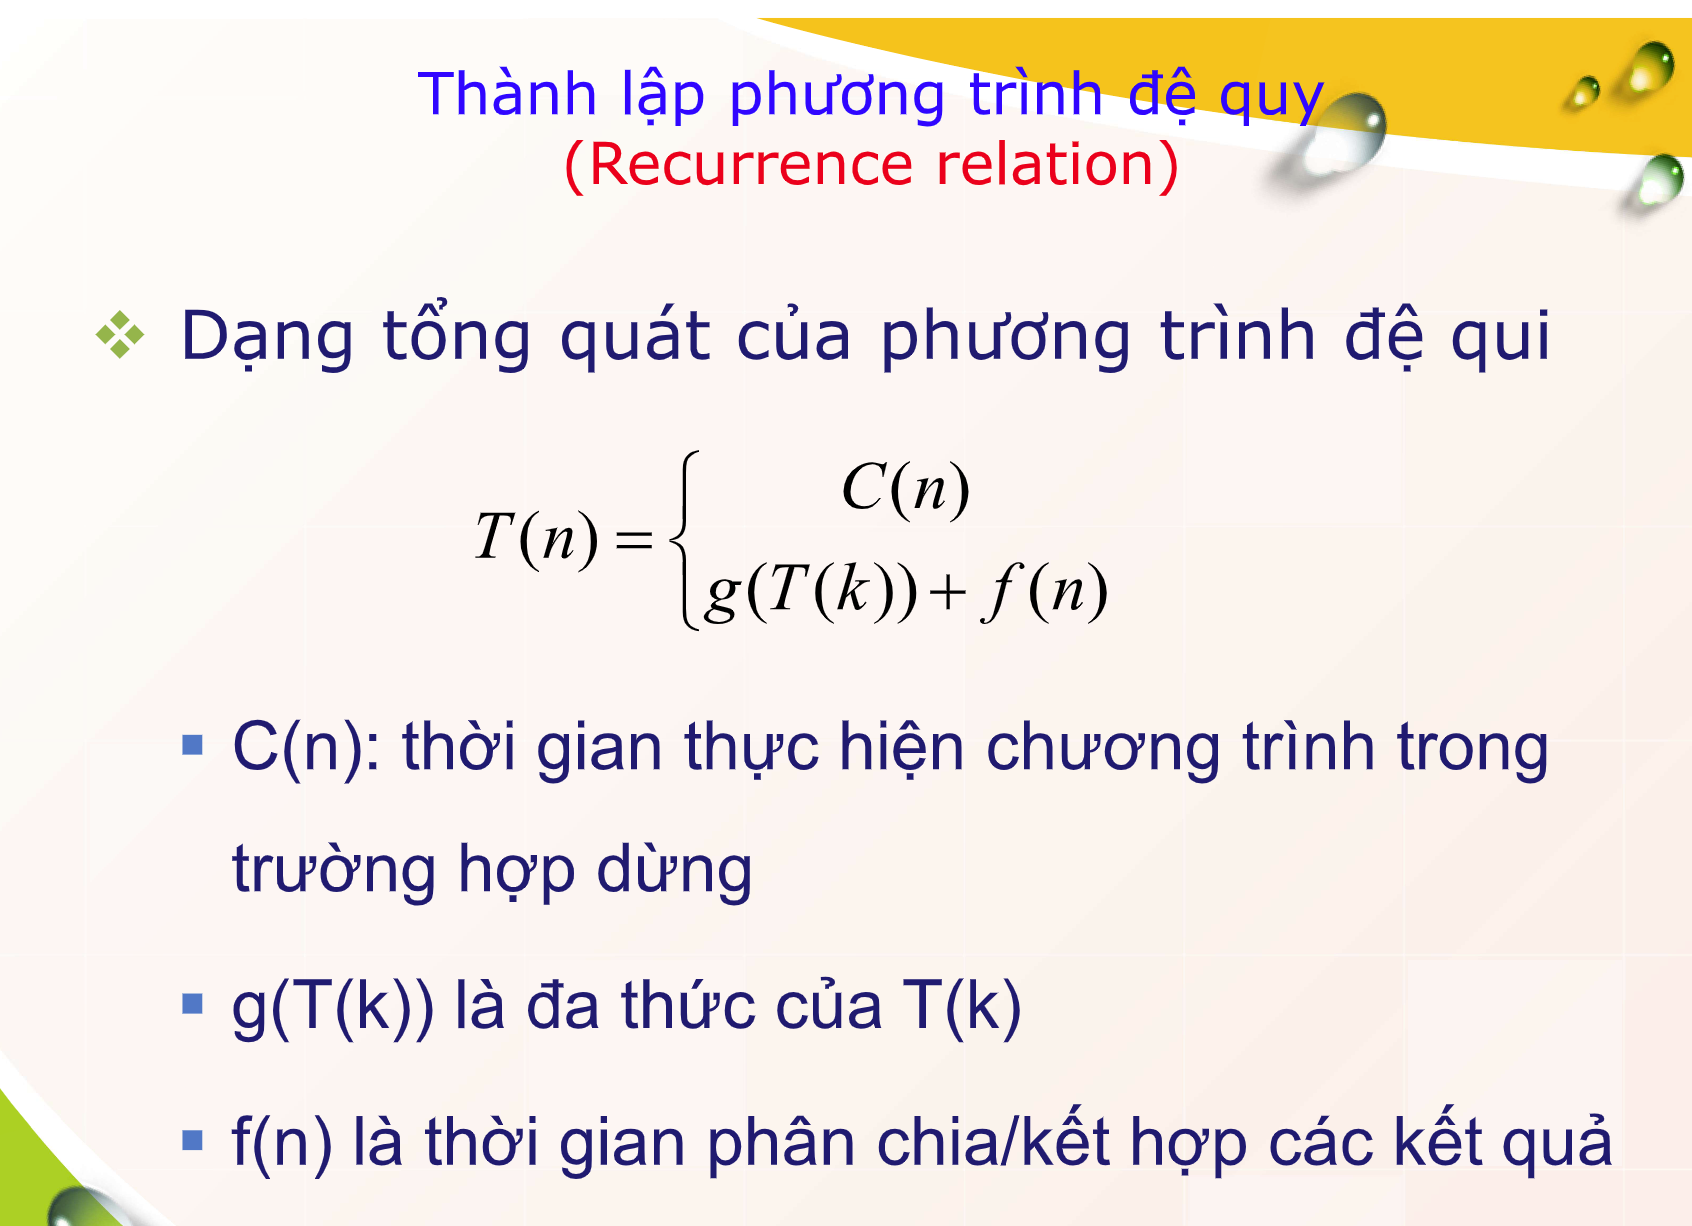

**1. Ý nghĩa tổng quát**
- Công thức T(n) đại diện cho Thời gian chạy (Time Complexity) của một thuật toán đệ quy với kích thước đầu vào là n
    - Trường hợp dừng (Base case): Khi bài toán đủ nhỏ để giải ngay
    - Trường hợp đệ quy (Recursive step): Khi bài toán còn lớn, cần chia nhỏ

**2. Phân tích các thành phần**

a. C(n) - Chi phí tại điểm dừng
- Đây là thời gian máy tính tiêu tốn khi thuật toán chạm đến điều kiện dừng (base case)
- Ví dụ: trong bài toán giai thừa, khi n = 0 ta return 1. Việc trả về số 1 này tốn khoảng thời gian hằng số (rất nhanh). Thường thì C(n) = O(1) (Hằng số)

b. $g(T(k)) + f(n)$ - Chi phí bước đệ quy
- Phần 1: $g(T(k))$ - Chi phí giải các bài toán con
    - Đây là tổng thời gian để giải quyết các nhánh đệ quy nhỏ hơn
    - Ví dụ:
        - Bài toán giai thừa: Gọi F(n - 1) một lần $\rightarrow$ $g(T(k)) = T(n - 1)$
        - Cụm thức $g(T(k)) = T(n-1)$ mà bạn thấy (hoặc đang suy luận từ ví dụ Giai thừa) có thể hiểu đơn giản là: Việc "đùn đẩy" công việc cho cấp dưới tốn bao nhiêu thời gian.
    - Phân tích kí hiệu:
        - $T$: Là thời gian (Time) hoặc chi phí để giải quyết bài toán.
        - $k$: Là kích thước của bài toán con (nhỏ hơn $n$). Trong ví dụ giai thừa, mỗi lần đệ quy ta giảm $n$ đi 1 đơn vị, nên $k = n - 1$.
        - $T(k)$ hay $T(n-1)$: Là thời gian để giải quyết bài toán con đó.
        - $g(...)$: Là hàm tổng quát mô tả cách chúng ta gọi đệ quy. Nó trả lời cho câu hỏi: "Chúng ta gọi bao nhiêu lần? Và gọi như thế nào?".

        $\rightarrow$ Vậy, khi viết $g(T(k)) = T(n-1)$, ý nghĩa là: Trong trường hợp cụ thể này (như tính Giai thừa), phần đệ quy chỉ đơn giản là gọi lại hàm đó 1 lần với kích thước giảm đi 1.
    - So sánh để thấy rõ sự khác biệt:
        - Giai thừa (n!): Giảm 1 đơn vị, gọi 1 lần nên công thức đệ quy $g(T(k))$ sẽ là $T(n-1)$
        - Tháp Hà Nội: Giảm 1 đơn vị, gọi 2 lần nên công thức đệ quy $g(T(k))$ sẽ là $2T(n-1)$
        - Tìm kiếm nhị phân: Chia đôi, gọi 1 lần nên công thức đệ quy $g(T(k))$ sẽ là $T(n/2)$
        - Merge Sort: Chia đôi, gọi 2 lần nên công thức đệ quy $g(T(k))$ sẽ là $2T(n/2)$
        - Fibonacci: Gọi 2 số trước đó nên công thức đệ quy $g(T(k))$ sẽ là $T(n-1) + T(n-2)$

- Phần 2: $f(n)$ - Chi phí phân chia/kết hợp
    - Đây là công sức của chính hàm hiện tại (không tính phần việc nhờ cấp dưới làm). Nó bao gồm thời gian để:
        - Chia bài toán to thành bài toán nhỏ
        - Hoặc gộp kết quả từ các bài toán nhỏ lại
    - Ví dụ:
        - Bài toán giai thừa: Sau khi có kết quả của $F(n-1)$, bạn tốn công làm phép nhân với n. Vậy $f(n) = O(1)$ (hoặc = 1 phép nhân)
        - Bài toán Merge Sort: Sau khi 2 nửa mảng đã sắp xếp xong, bạn tốn công merge chúng lại. Việc này tốn $O(n)$. Vậy $f(n) = n$

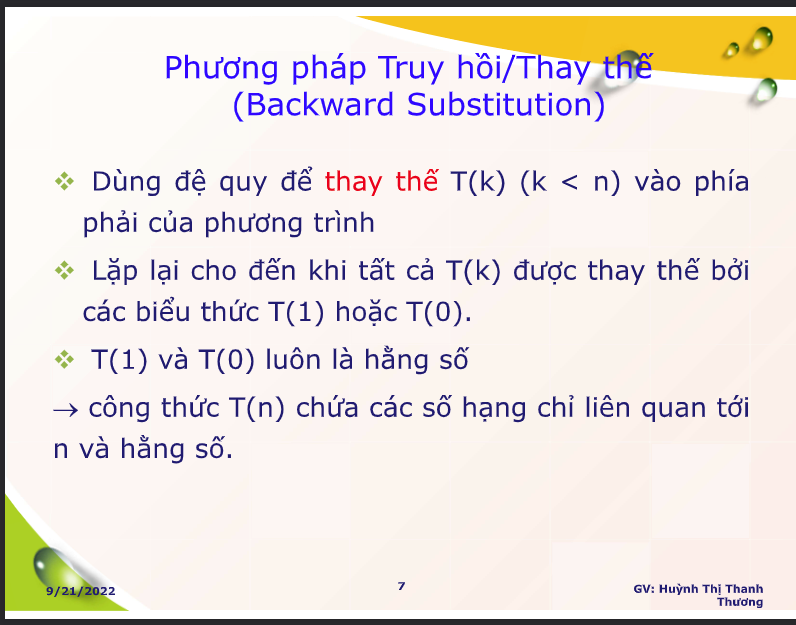

**1. Dùng đệ quy để thay thế $T(k)$ vào phía phải của phương trình**

- Ý nghĩa: Đây là bước bóc tách, dùng chính định nghĩa của hàm đệ quy để triển khai cái thành phần bên trong ra
- Ví dụ
    - Phương trình gốc: $M(n) = \mathbf{M(n-1)} + 1$
    - Phía bên phải đang chứa $M(n-1)$.
    - Hành động "thay thế": Bạn thay cụm $M(n-1)$ bằng cụm $[M(n-2) + 1]$.
    - Kết quả: $M(n) = [\mathbf{M(n-2)} + 1] + 1$.

**2. Lặp lại cho đến khi tất cả T(k) được thay thế bởi T(1) hoặc T(0)**

- Ý nghĩa: Bạn không thể thay thế mãi mãi. Bạn phải lặp lại quy trình này cho đến khi chạm "đáy" (Base case).
- Tại sao lại là T(1) hoặc T(0)? Vì trong lập trình đệ quy, điều kiện dừng thường là khi $n$ giảm về 1 hoặc về 0.
- Ví dụ:
    - Bạn cứ thay thế mãi: $M(n-3) \dots M(n-4) \dots$
    - Cuối cùng bạn sẽ gặp số hạng $M(n-n)$ tức là $M(0)$.
    - Lúc này phương trình không còn chữ $T$ hay $M$ nào ở vế phải nữa ngoại trừ cái $M(0)$ cuối cùng này.

**3. T(1) và T(0) luôn là hằng số**

- Ý nghĩa: Đây là chìa khóa để giải quyết bài toán. Giá trị tại điểm dừng luôn là một con số cụ thể (biết trước), không phải là một công thức mơ hồ.
- Ví dụ:
    - Trong bài giai thừa, $M(0) = 0$. Đây là một hằng số.
    - Nhờ biết nó bằng 0, ta mới triệt tiêu được nó khỏi phương trình.

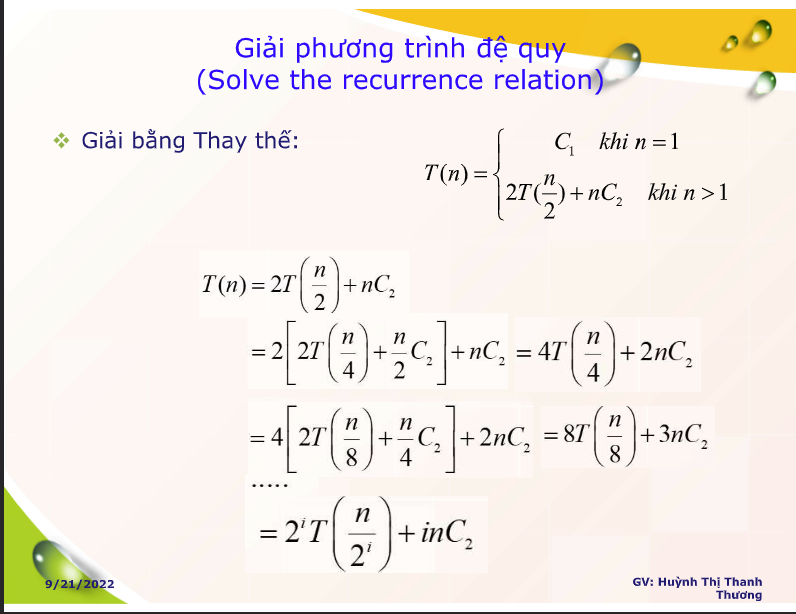

- Đây là phương trình đệ quy điển hình của thuật toán Merge Sort (Sắp xếp trộn). Ta sẽ giải quyết bài toán này bằng phương pháp Thay thế (Substitution) từng bước một, đúng như những gì trên slide

**1. Đề bài (Phương trình ban đầu)**

$$T(n) = 2T\left(\frac{n}{2}\right) + nC_2$$

- Ý nghĩa: Để giải quyết bài toán kích thước n, ta chia nó thành 2 bài toán con kích thước n/2, và tốn thêm chi phí $nC_2$ để kết hợp kết quả (bước merge)
- Mục tiêu: Loại bỏ T ở vế phải để tìm công thức tổng quát
    - Lý do bước merge tốn chi phí O(n)
        - Quy tắc hai ngón tay:
            - Giả sử bạn có 2 chồng bài đã được sắp xếp (từ nhỏ đến lớn). Nhiệm vụ của bạn là gộp chúng thành 1 chồng bài lớn cũng được sắp xếp.
                - Chồng trái (Left): [2, 5, 8]
                - Chồng phải (Right): [3, 6, 9]
                - Tổng cộng $n = 6$ lá bài.
            - Cách làm:
                - Bạn đặt ngón tay trái lên lá đầu tiên của chồng trái (số 2).
                - Bạn đặt ngón tay phải lên lá đầu tiên của chồng phải (số 3).
                - So sánh: Số 2 nhỏ hơn số 3 $\rightarrow$ Nhặt số 2 bỏ vào chồng kết quả. Dời ngón tay trái sang số tiếp theo (số 5).
                - So sánh tiếp: Số 5 lớn hơn số 3 $\rightarrow$ Nhặt số 3 bỏ vào chồng kết quả. Dời ngón tay phải sang số tiếp theo (số 6).
        - Hãy để ý quy luật trong ví dụ trên:
            - Mỗi lần so sánh, bạn chắc chắn chọn được 1 con số để đưa vào vị trí đúng trong mảng kết quả.
            - Để điền đầy mảng kết quả có kích thước $n$, bạn cần thực hiện hành động (so sánh và di chuyển) đúng $n$ lần.
        - Chính xác hơn về mặt toán học:
            - Trong trường hợp tốt nhất: Bạn cần $n/2$ phép so sánh.
            - Trong trường hợp xấu nhất: Bạn cần $n-1$ phép so sánh.
            - Số lần di chuyển phần tử: Luôn luôn là $n$ lần (vì phần tử nào cũng phải được bốc sang mảng mới).
        - Vì số lượng phép tính (so sánh + di chuyển) tỉ lệ thuận trực tiếp với tổng số phần tử $n$, nên ta nói chi phí của bước này là $O(n)$ hay $f(n) = n$.

**2. Bước 1: Thay thế lần thứ nhất**

- Chúng ta cần biết $T(n/2)$ bằng bao nhiêu. Dựa vào công thức gốc, ta thay n bằng n/2:
$$T\left(\frac{n}{2}\right) = 2T\left(\frac{n}{4}\right) + \frac{n}{2}C_2$$

- Bây giờ, thay thế cụm này vào phương trình gốc
$$T(n) = 2\left[ \underbrace{2T\left(\frac{n}{4}\right) + \frac{n}{2}C_2}_{\text{Đây là } T(n/2)} \right] + nC_2$$

- Nhân phân phối vào:
$$T(n) = 4T\left(\frac{n}{4}\right) + 2 \cdot \frac{n}{2}C_2 + nC_2$$
$$T(n) = 4T\left(\frac{n}{4}\right) + nC_2 + nC_2$$
$$\Rightarrow T(n) = 4T\left(\frac{n}{4}\right) + 2nC_2$$

**3. Bước 3: Thay thế lần thứ hai**

- Tiếp tục, ta cần xử lý $T(n/4)$. Dựa vào công thức gốc, thay n bằng n/4:
$$T\left(\frac{n}{4}\right) = 2T\left(\frac{n}{8}\right) + \frac{n}{4}C_2$$

- Thay cụm này vào kết quả của bước 1:
$$T(n) = 4\left[ \underbrace{2T\left(\frac{n}{8}\right) + \frac{n}{4}C_2}_{\text{Đây là } T(n/4)} \right] + 2nC_2$$
- Nhân phân phối vào:
$$T(n) = 8T\left(\frac{n}{8}\right) + 4 \cdot \frac{n}{4}C_2 + 2nC_2$$
$$T(n) = 8T\left(\frac{n}{8}\right) + nC_2 + 2nC_2$$
$$\Rightarrow T(n) = 8T\left(\frac{n}{8}\right) + 3nC_2$$

**4. Bước 3: Tìm quy luật tổng quát (Pattern Recognition)**

- Hãy nhìn lại kết quả sau các bươc thay thế để tìm quy luật với biến đếm i (số lần thay thế):
    - Lần 1 ($i=1$): $2^1 T\left(\frac{n}{2^1}\right) + 1 \cdot nC_2$
(Kết quả: $2T(n/2) + nC_2$)
    - Lần 2 ($i=2$): $2^2 T\left(\frac{n}{2^2}\right) + 2 \cdot nC_2$
(Kết quả: $4T(n/4) + 2nC_2$)
    - Lần 3 ($i=3$): $2^3 T\left(\frac{n}{2^3}\right) + 3 \cdot nC_2$
(Kết quả: $8T(n/8) + 3nC_2$)

$\Rightarrow$ Quy luật tổng quát ở bước thứ $i$ (Dòng cuối cùng của slide):
$$T(n) = 2^i T\left(\frac{n}{2^i}\right) + i \cdot nC_2$$

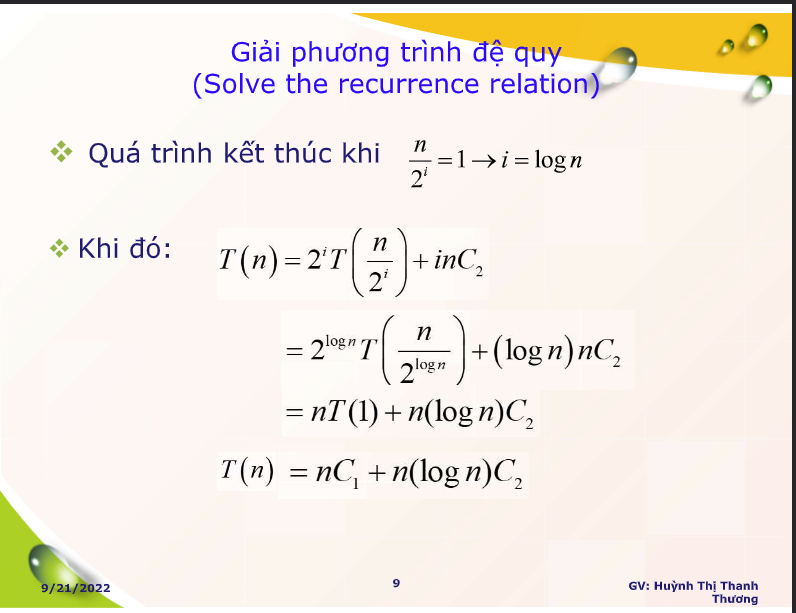

**5. Bước 4: Xác định điểm dừng (Khi nào thì hết chia ?)**

- Quá trình kết thúc khi $\frac{n}{2^i} = 1 \rightarrow i = \log n$
    - Ở slide trước, ta thấy kích thước bài toán cứ giảm dần: $\frac{n}{2}, \frac{n}{4}, \frac{n}{8}, \dots, \frac{n}{2^i}$.
    - Chúng ta không thể chia mãi được. Chúng ta phải dừng lại khi kích thước bài toán chỉ còn 1 phần tử (Base case).
    - Vậy ta đặt phương trình: $\frac{n}{2^i} = 1$.
    - Giải phương trình này:
    $$n = 2^i \Rightarrow \log_2 n = \log_2 (2^i) \Rightarrow i = \log_2 n$$

    - Ý nghĩa: Để chia một mảng kích thước $n$ xuống còn 1 phần tử, bạn cần thực hiện đúng $\log n$ lần chia. (Ví dụ: 8 phần tử cần chia 3 lần: $8 \to 4 \to 2 \to 1$, và $\log_2 8 = 3$).

**6. Bước 5: Thay thế 'điểm dừng' vào công thức (The Substitution)**

- Bây giờ ta đã biết $i = \log(n)$. Hãy lấy giá trị này thay ngược vào công thức tổng quát đã tìm ở bước trước
- Công thức cũ:
$$T(n) = 2^i T\left(\frac{n}{2^i}\right) + i \cdot nC_2$$

- Quá trình diễn ra thay thế:
    - Dòng 1 (Thay thế trực tiếp):
    $$= 2^{\log n} T\left(\frac{n}{2^{\log n}}\right) + (\log n) n C_2$$
    - Dòng 2(Rút gọn toán học): ở đây sử dụng 2 tính chất toán học quan trọng
        - $2^{\log_2 n} = n$ (Đây là định nghĩa cơ bản của logarit).
        - $\frac{n}{2^{\log n}} = \frac{n}{n} = 1$.
        - Vậy biểu thức trở thành:
        $$= n \cdot T(1) + n(\log n)C_2$$
    - Dòng 3 (Đưa về hằng số):
        - $T(1)$ là thời gian xử lý khi mảng chỉ còn 1 phần tử. Slide gọi chi phí này là hằng số $C_1$.
        - Vậy ta có kết quả cuối cùng:
        $$T(n) = nC_1 + n(\log n)C_2$$

**7. Kết luận về độ phức tạp (Big-O)**

- Mặc dù slide dừng lại ở công thức cụ thể $nC_1 + n(\log n)C_2$, nhưng chúng ta có thể suy ra Big-O ngay lập tức:
    - Thành phần thứ nhất: $n \cdot C_1$ (Bậc 1).
    - Thành phần thứ hai: $n \log n \cdot C_2$ (Bậc $n \log n$).
    - Vì $n \log n$ tăng trưởng nhanh hơn $n$, nên nó là thành phần quyết định.
$\Rightarrow$ $T(n) \in O(n \log n)$

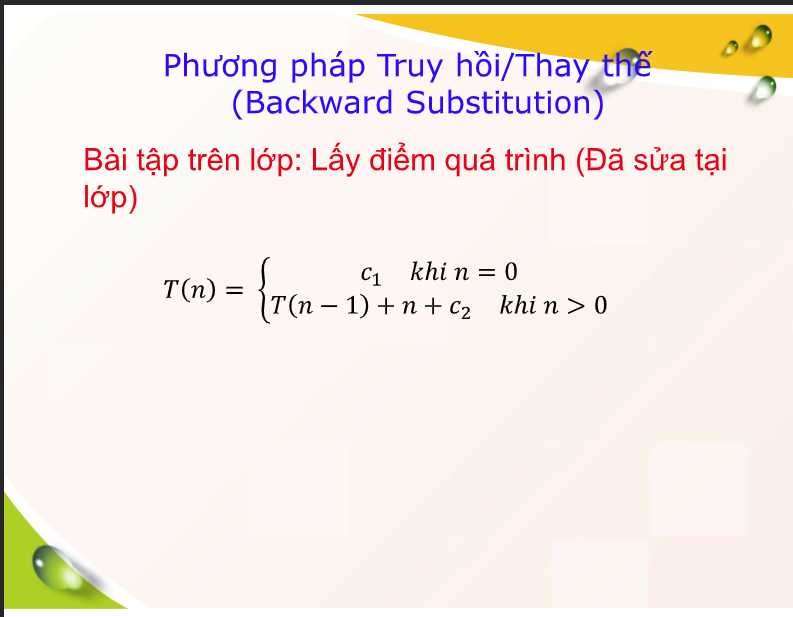

**1. Bước 1: Triển khai để tìm quy luật**

- Ta bắt đầu thay thế ngược $T(n-1), T(n-2)...$ để xem biểu thức biến đổi thế nào.
    - Lần 1: Viết lại công thức gốc
    $$T(n) = T(n-1) + n + c_2$$
    - Lần 2: Thay $T(n-1)$ bằng $[T(n-2) + (n-1) + c_2]$
    $$T(n) = [T(n-2) + (n-1) + c_2] + n + c_2$$
    $$T(n) = T(n-2) + (n-1) + n + 2c_2$$
    - Lần 3: Thay $T(n-2)$ bằng $[T(n-3) + (n-2) + c_2]$
    $$T(n) = [T(n-3) + (n-2) + c_2] + (n-1) + n + 2c_2$$
    $$T(n) = T(n-3) + (n-2) + (n-1) + n + 3c_2$$

**2. Bước 2: Tổng quát hóa**

- Nhìn vào kết quả "Rút gọn" ở Lần 3, ta thấy quy luật sau $i$ lần thay thế:
    - Phần đệ quy: $T(n-i)$.
    - Phần hằng số $c_2$: Được nhân lên $i$ lần $\rightarrow i \cdot c_2$.
    - Phần cộng dồn $n$: Là tổng của chuỗi số giảm dần từ $n$ xuống

$\Rightarrow$ Công thức tại bước thứ $i$:
$$T(n) = T(n-i) + \underbrace{[ (n-i+1) + \dots + (n-1) + n ]}_{\text{Tổng các số nguyên}} + i \cdot c_2$$

**3. Bước 3: Xác định điểm dừng**

- Chúng ta cần triệt tiêu $T(n-i)$.
Nhìn vào đề bài, điều kiện dừng (Base case) xảy ra khi $n=0$, tại đó $T(0) = c_1$.
- Để $n-i = 0$, ta chọn:
$$\mathbf{i = n}$$

**4. Bước 4: Thay thế cuối cùng và tính toán**

- Thay $i = n$ vào công thức tổng quát ở Bước 2:
$$T(n) = \underbrace{T(0)}_{\text{Giá trị } c_1} + \underbrace{[ (1) + (2) + \dots + (n-1) + n ]}_{\text{Tổng từ 1 đến n}} + n \cdot c_2$$
- Bây giờ ta áp dụng các công thức toán học cơ bản:
    - $T(0) = c_1$ (Theo đề bài).
    - Tổng $1 + 2 + \dots + n = \frac{n(n+1)}{2}$ (Tổng cấp số cộng).
- Kết quả cuối cùng:
$$T(n) = c_1 + \frac{n(n+1)}{2} + n c_2$$
- Triển khai ra dạng đa thức để thấy rõ độ phức tạp:
$$T(n) = c_1 + \frac{1}{2}n^2 + \frac{1}{2}n + n c_2$$
$$T(n) = \frac{1}{2}n^2 + \left(\frac{1}{2} + c_2\right)n + c_1$$

**5. Kết luận**
- Vì thành phần bậc cao nhất trong công thức là $n^2$, ta kết luận:
$$T(n) \in O(n^2)$$